# Week 2 
## Tesla Deliveries Dataset (2015–2025)
### Name: Pramathesh Kumar

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.stattools import adfuller


### loading datasets

In [26]:


df = pd.read_csv("datasets/tesla_deliveries_dataset_2015_2025.csv")
df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


### dataframe

In [3]:

print("shape:", df.shape)


print(df.columns)

print(df.info())

print(df.describe())

shape: (2640, 12)
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 

### missing values

In [4]:
print("Missing Val:")
print(df.isnull().sum())

print("total-:", df.duplicated().sum())

Missing Val:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
total-: 0


### EDA
understanding distributions, relationships, and trends


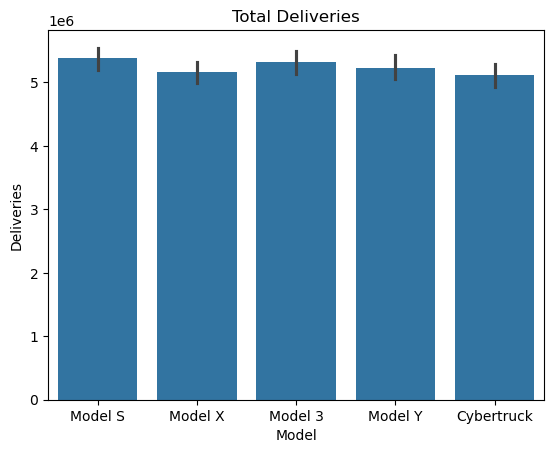

In [5]:



sns.barplot(x='Model', y='Estimated_Deliveries', data=df, estimator=sum)

plt.title("Total Deliveries")
plt.xlabel("Model")
plt.ylabel("Deliveries")

plt.show()

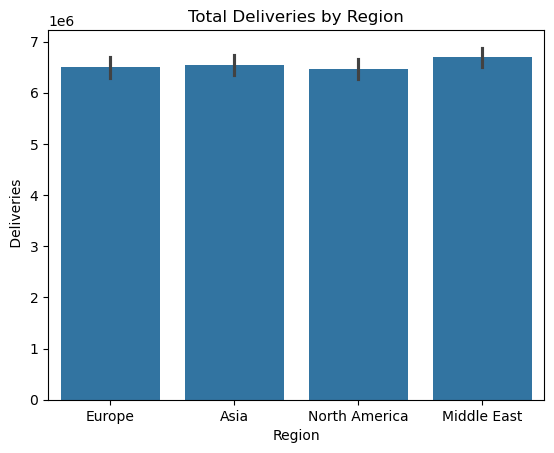

In [6]:

sns.barplot(x='Region', y='Estimated_Deliveries', data=df, estimator=sum)

plt.title("Total Deliveries by Region")
plt.xlabel("Region")
plt.ylabel(" Deliveries")
plt.show()

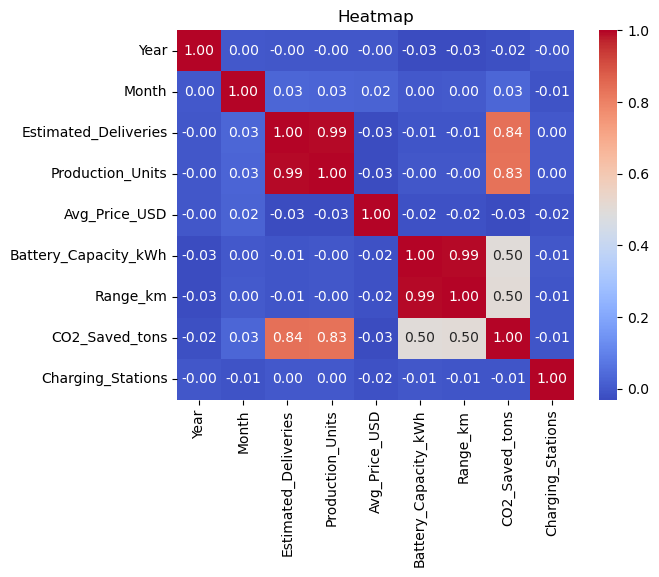

In [7]:


numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Heatmap")

plt.show()

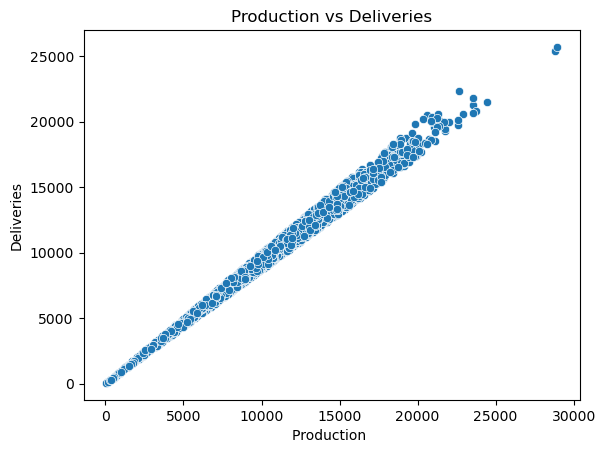

In [8]:


sns.scatterplot(
    x='Production_Units',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Production vs Deliveries")
plt.xlabel("Production ")
plt.ylabel("Deliveries")

plt.show()

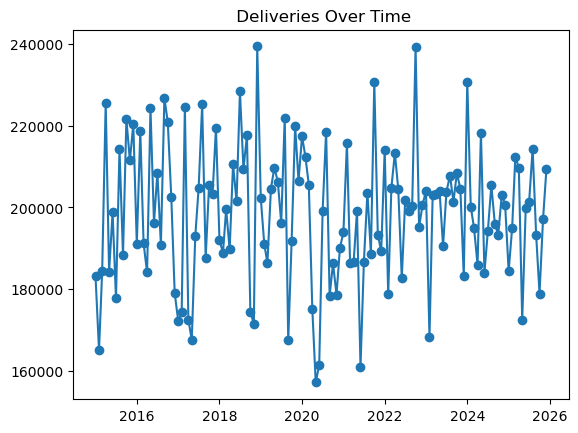

In [9]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-01'
)

monthly = (
    df.groupby('Date', as_index=False)['Estimated_Deliveries']
      .sum()
)





plt.plot(
    monthly['Date'],
    monthly['Estimated_Deliveries'],
    marker='o'
)

plt.title(" Deliveries Over Time")

plt.show()




### Feature Engineering
LabelEncoder - categorical columns

In [10]:


le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df['Region'] = le_region.fit_transform(df['Region'])
df['Model'] = le_model.fit_transform(df['Model'])
df['Source_Type'] = le_source.fit_transform(df['Source_Type'])

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,2023-05-01
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,2015-02-01
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,2019-01-01
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,2021-02-01
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,2016-12-01


### feature engineering
creating time series feature
Deliveries_Lag1 - previous period's deliveries

Rolling_Mean_3 - 3-period moving average

these are temporal patterns

In [11]:
df = df.sort_values(by=['Year', 'Month']).reset_index(drop=True)

df['Deliveries_Lag1'] = df['Estimated_Deliveries'].shift(1)
df['Deliveries_Lag1'].fillna(df['Deliveries_Lag1'].mean(), inplace=True)

df['Rolling_Mean_3'] = df['Estimated_Deliveries'].rolling(window=3).mean()
df['Rolling_Mean_3'].fillna(df['Rolling_Mean_3'].mean(), inplace=True)

print(df[['Estimated_Deliveries','Deliveries_Lag1','Rolling_Mean_3']].head())

print("\nMissing values:")
print(df[['Deliveries_Lag1','Rolling_Mean_3']].isnull().sum())

   Estimated_Deliveries  Deliveries_Lag1  Rolling_Mean_3
0                 10348      9921.649488     9921.864797
1                 12446     10348.000000     9921.864797
2                 10835     12446.000000    11209.666667
3                  8122     10835.000000    10467.666667
4                 13902      8122.000000    10953.000000

Missing values:
Deliveries_Lag1    0
Rolling_Mean_3     0
dtype: int64


C:\Users\Pramathesh\AppData\Local\Temp\ipykernel_7536\2802198437.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Deliveries_Lag1'].fillna(df['Deliveries_Lag1'].mean(), inplace=True)
C:\Users\Pramathesh\AppData\Local\Temp\ipykernel_7536\2802198437.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

In [12]:
X = df.drop(columns=['Estimated_Deliveries', 'Date'])
y = df['Estimated_Deliveries']

print("Feature ", X.shape)
print("Target ", y.shape)

Feature  (2640, 13)
Target  (2640,)


### Chronological Train Test Split

In [13]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("train", len(X_train))
print("test ", len(X_test))

train 2112
test  528


### Linear Regression
evaluation - MAE, RMSE, and R square 

Plot Actual vs Predicted


In [14]:


lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)


print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

MAE  : 317.93
RMSE : 386.69
R2   : 0.9889


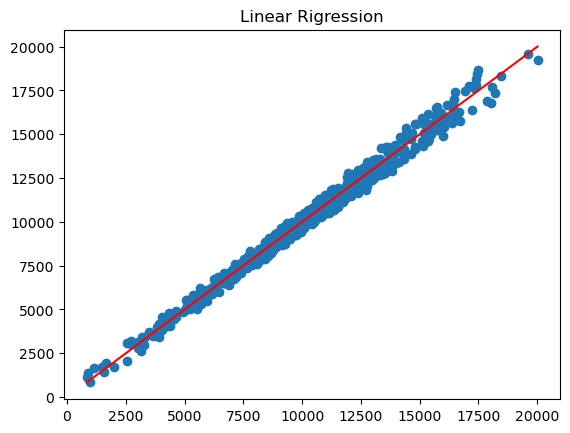

In [15]:


plt.scatter(y_test, y_pred_lr)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.title("Linear Rigression")

plt.show()

### 5 fold cross validation

In [16]:


kf = KFold(n_splits=5, shuffle=False)

cv_scores = cross_val_score(lr, X_train, y_train, cv=kf, scoring='r2')

print("R2 Score")

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print(" R2 :", cv_scores.mean())
print("Std :", cv_scores.std())

R2 Score
Fold 1: 0.9895
Fold 2: 0.9911
Fold 3: 0.9903
Fold 4: 0.9915
Fold 5: 0.9908
 R2 : 0.9906463642126315
Std : 0.0007020081163607531


### Random Forest with GridSearchCV

In [17]:


param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Parameters:", grid_search.best_params_)
print("Cross Val R2:", grid_search.best_score_)

Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Cross Val R2: 0.9886984584376393


In [18]:
best_rf = grid_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

MAE  : 332.07
RMSE : 411.06
R²   : 0.9874


### Feature Importance
most influential features from the best Random Forest model.

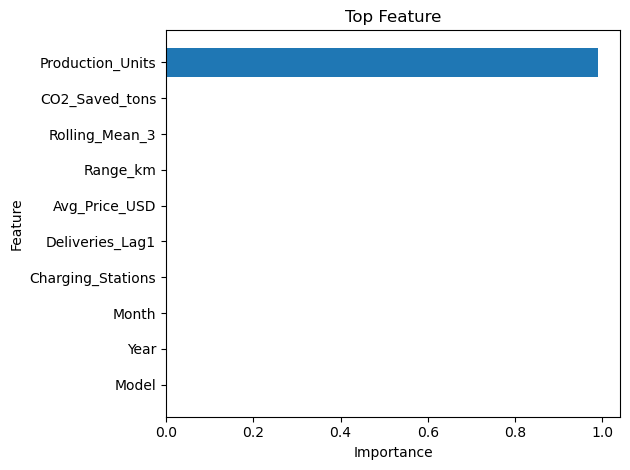

In [19]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)



plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title("Top Feature")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Stationarity Test (ADF)
check if the time series is stationary

 p-value < 0.05 - reject the null hypothesis -- series is stationary
 -- mean and variance are stable over time

In [20]:


result = adfuller(df['Estimated_Deliveries'])

print("adf :", result[0])
print("p-val :", result[1])


for key, value in result[4].items():
    print(f"{key}: {value:.4f}")

if result[1] < 0.05:
    print("stationary")
else:
    print(" non stationary ")

adf : -24.662112249181472
p-val : 0.0
1%: -3.4328
5%: -2.8626
10%: -2.5674
stationary


### Forecast Comparison Table

In [21]:
forecast = pd.DataFrame({
    "Actual": y_test.values,
    "LR": y_pred_lr,
    "RF": y_pred_rf
})

forecast["LR error"] = (
    abs(forecast["Actual"] - forecast["LR"])
    / forecast["Actual"] * 100
)

forecast["RF error"] = (
    abs(forecast["Actual"] - forecast["RF"])
    / forecast["Actual"] * 100
)

forecast.head(20)

,Actual,LR,RF,LR error,RF error
0,9476,9063.528804,8995.171667,4.352799,5.074170
1,8179,8448.374747,8439.035000,3.293492,3.179301
2,14430,15095.699516,15257.505000,4.613302,5.734615
3,15912,16210.487814,15904.385000,1.875866,0.047857
4,15077,14598.067428,14786.235000,3.176577,1.928534
5,11280,11383.732099,11258.950000,0.919611,0.186613
6,4070,3964.099473,4105.745000,2.601979,0.878256
7,11636,11572.280772,11583.745000,0.547604,0.449080
8,12540,12514.509089,12292.035000,0.203277,1.977392
9,12717,11842.113838,11788.588000,6.879658,7.300558


### Model Comparison Summary

In [22]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, rf_mae],
    'RMSE': [rmse, rf_rmse],
    'R2': [r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,317.931814,386.694736,0.988886
1,Random Forest,332.065329,411.057944,0.987441
